In [3]:
import sys
from pathlib import Path

# src-layout package root for the AngioEye repo (postprocess/, pipelines/, input_output/ live under here)
REPO_SRC = Path("/Users/admin/Developer/AngioEye/src")
if str(REPO_SRC) not in sys.path:
    sys.path.insert(0, str(REPO_SRC))

import h5py
import numpy as np
import pandas as pd

from pipelines import load_pipeline_catalog
from pipeline_engine.execution import run_pipeline_file
from input_output.output_paths import h5_output_dir
from input_output.hdf5_schema import find_pipeline_group
from input_output.hdf5_io import read_dataset

from postprocess.composite_scoring.metrics import (
    METRICS,
    DOMAINS,
    PLOT_VESSEL_TYPE,
    VESSEL_TYPES,
    REPRESENTATIONS,
)
from postprocess.composite_scoring.scoring import (
    append_scores_to_file,
    score_records_for_tree,
    _finite_scalar,
)

DATA_ROOT = Path("/Users/admin/Desktop/langevin-internship/composite-scoring/WAS scoring")
PROCESSED_ROOT = DATA_ROOT / "_processed"

list(METRICS.keys())


['stroke_fraction',
 'med_displacement_timing',
 'low_freq_spectral_fraction',
 'late_cycle_mean_fraction',
 'participation_ratio_eff_supp',
 'resistivity_index',
 'pulsatility_index',
 'near_peak_crest_width']

In [4]:
def cohort_files(root: Path) -> dict[str, dict[str, list[Path]]]:
    manifest: dict[str, dict[str, list[Path]]] = {}
    for cohort_dir in sorted(root.iterdir()):
        if not cohort_dir.is_dir():
            continue
        if cohort_dir.name in {"zips", "_processed"} or cohort_dir.name.startswith("."):
            continue
        groups: dict[str, list[Path]] = {}
        for group_dir in sorted(cohort_dir.iterdir()):
            if not group_dir.is_dir():
                continue
            files = sorted(group_dir.glob("*.h5"))
            if files:
                groups[group_dir.name] = files
        if groups:
            manifest[cohort_dir.name] = groups
    return manifest


manifest = cohort_files(DATA_ROOT)
for cohort, groups in manifest.items():
    print(cohort, {group: len(files) for group, files in groups.items()})


251219_BOM0753_no_BL2 {'BL': 7, 'F': 12}
260609_BOM0753 Valsalva {'BL': 6, 'Valsalva_2': 4}
260609_GOA Valsalva {'BL': 4, 'Valsalva': 5}
260609_GUJ Valsalva {'BL': 4, 'Valsalva': 9}
GLONGI_select {'after': 17, 'before': 17}
POAG_vs_CTRL {'CTRL': 262, 'POAG': 245}
alternate_pressure {'ctrl': 13, 'pressure': 13}


In [5]:
available_pipelines, _ = load_pipeline_catalog()
pipeline_registry = {p.name: p for p in available_pipelines}
wsm_pipeline = pipeline_registry["waveform_shape_metrics"]


def processed_path_for(raw_path: Path) -> Path:
    relative_parent = raw_path.parent.relative_to(DATA_ROOT)
    return h5_output_dir(PROCESSED_ROOT) / relative_parent / f"{raw_path.stem}_wsm.h5"


def ensure_waveform_shape_metrics(raw_path: Path) -> Path | None:
    expected = processed_path_for(raw_path)
    if expected.exists():
        return expected
    relative_parent = raw_path.parent.relative_to(DATA_ROOT)
    return run_pipeline_file(
        raw_path,
        [wsm_pipeline],
        PROCESSED_ROOT,
        output_relative_parent=relative_parent,
        output_filename=f"{raw_path.stem}_wsm.h5",
    )


# Real acquisitions are messy -- some files won't have everything the pipeline
# expects (e.g. a missing Artery/VelocityPerBeat group). Skip and record those
# rather than aborting the whole batch, mirroring how run_composite_scoring
# collects per-file failures instead of stopping on the first one.
pipeline_failures: list[str] = []
processed_manifest: dict[str, dict[str, list[Path]]] = {}
for cohort, groups in manifest.items():
    processed_manifest[cohort] = {}
    for group, files in groups.items():
        processed_paths: list[Path] = []
        for raw_path in files:
            try:
                processed_paths.append(ensure_waveform_shape_metrics(raw_path))
            except Exception as exc:  # noqa: BLE001
                pipeline_failures.append(
                    f"{cohort}/{group}/{raw_path.name}: {type(exc).__name__}: {exc}"
                )
        processed_manifest[cohort][group] = processed_paths
        print(f"{cohort}/{group}: {len(processed_paths)}/{len(files)} file(s) ready")

if pipeline_failures:
    print(f"\n{len(pipeline_failures)} file(s) skipped:")
    for failure in pipeline_failures:
        print(f"  {failure}")


251219_BOM0753_no_BL2/BL: 7/7 file(s) ready
251219_BOM0753_no_BL2/F: 10/12 file(s) ready
260609_BOM0753 Valsalva/BL: 6/6 file(s) ready
260609_BOM0753 Valsalva/Valsalva_2: 4/4 file(s) ready
260609_GOA Valsalva/BL: 4/4 file(s) ready
260609_GOA Valsalva/Valsalva: 4/5 file(s) ready
260609_GUJ Valsalva/BL: 2/4 file(s) ready
260609_GUJ Valsalva/Valsalva: 6/9 file(s) ready
GLONGI_select/after: 12/17 file(s) ready
GLONGI_select/before: 15/17 file(s) ready
POAG_vs_CTRL/CTRL: 260/262 file(s) ready
POAG_vs_CTRL/POAG: 241/245 file(s) ready
alternate_pressure/ctrl: 13/13 file(s) ready
alternate_pressure/pressure: 13/13 file(s) ready

21 file(s) skipped:
  251219_BOM0753_no_BL2/F/251219_BOM0753_15_HD_1_EF_1_output.h5: RuntimeError: Pipeline 'waveform_shape_metrics' failed: KeyError: 'Unable to synchronously open object (component not found)'
  at /Users/admin/Developer/AngioEye/src/pipelines/waveform_shape_metrics.py:1581 in run()
    T = np.asarray(h5file[self.T_input])
    ^
  251219_BOM0753_no_BL

In [6]:
def extract_metric_values(
    processed_path: Path, vessel_type: str = PLOT_VESSEL_TYPE
) -> dict[str, dict[str, float | None]]:
    values: dict[str, dict[str, float | None]] = {key: {} for key in METRICS}
    with h5py.File(processed_path, "r") as h5:
        source_group = find_pipeline_group(h5, "waveform_shape_metrics")
        if source_group is None:
            for metric_key in METRICS:
                for representation in REPRESENTATIONS:
                    values[metric_key][representation] = None
            return values

        for representation in REPRESENTATIONS:
            for metric_key, metric in METRICS.items():
                paths = metric.derived_paths(vessel_type, representation)
                if paths is None:
                    raw = read_dataset(
                        source_group, metric.path(vessel_type, representation), default=None
                    )
                    value = _finite_scalar(raw) if raw is not None else None
                else:
                    numerator = read_dataset(source_group, paths[0], default=None)
                    denominator = read_dataset(source_group, paths[1], default=None)
                    if numerator is None or denominator is None:
                        value = None
                    else:
                        numerator = np.asarray(numerator, dtype=float)
                        denominator = np.asarray(denominator, dtype=float)
                        with np.errstate(divide="ignore", invalid="ignore"):
                            ratio = np.where(
                                np.isfinite(denominator) & (denominator != 0),
                                numerator / denominator,
                                np.nan,
                            )
                        value = _finite_scalar(ratio)
                values[metric_key][representation] = value
    return values


rows = []
for cohort, groups in processed_manifest.items():
    for group, paths in groups.items():
        for path in paths:
            # Keep the real pipeline exercised end to end (RWAS/RWAS4 written to file).
            append_scores_to_file(path)
            metric_values = extract_metric_values(path)
            for metric_key in METRICS:
                for representation in REPRESENTATIONS:
                    rows.append(
                        {
                            "cohort": cohort,
                            "group": group,
                            "file": path.name,
                            "representation": representation,
                            "metric": metric_key,
                            "value": metric_values[metric_key][representation],
                        }
                    )

long_df = pd.DataFrame(rows)
wide_df = long_df.pivot_table(
    index=["cohort", "group", "file", "representation"],
    columns="metric",
    values="value",
).reset_index()
wide_df.head()


metric,cohort,group,file,representation,late_cycle_mean_fraction,low_freq_spectral_fraction,med_displacement_timing,near_peak_crest_width,participation_ratio_eff_supp,pulsatility_index,resistivity_index,stroke_fraction
0,251219_BOM0753_no_BL2,BL,251219_BOM0753_0_HD_1_EF_0_output_wsm.h5,bandlimited,0.684636,0.603044,0.398309,0.652344,0.931829,0.961127,0.603932,0.428733
1,251219_BOM0753_no_BL2,BL,251219_BOM0753_0_HD_1_EF_0_output_wsm.h5,raw,0.704467,0.595986,0.392337,0.714844,0.928619,1.030532,0.647433,0.433497
2,251219_BOM0753_no_BL2,BL,251219_BOM0753_1_HD_1_EF_0_output_wsm.h5,bandlimited,0.713615,0.565390,0.403191,0.671875,0.934980,0.929036,0.580279,0.427982
3,251219_BOM0753_no_BL2,BL,251219_BOM0753_1_HD_1_EF_0_output_wsm.h5,raw,0.732313,0.546327,0.399577,0.671875,0.933174,1.005084,0.627864,0.429823
4,251219_BOM0753_no_BL2,BL,251219_BOM0753_2_HD_1_EF_0_output_wsm.h5,bandlimited,0.666692,0.597375,0.390380,0.605469,0.920441,1.068735,0.633689,0.439353


In [7]:
metric_cols = list(METRICS.keys())

metric_to_domain = {
    metric_key: domain_name
    for domain_name, domain in DOMAINS.items()
    for metric_key in domain.metrics
}
print("metric -> domain:")
for metric_key in metric_cols:
    print(f"  {metric_key:32s} {metric_to_domain[metric_key]}")

correlations: dict[str, dict[str, pd.DataFrame]] = {}
for representation in REPRESENTATIONS:
    subset = wide_df.loc[wide_df["representation"] == representation, metric_cols].dropna()
    correlations[representation] = {
        "pearson": subset.corr(method="pearson"),
        "spearman": subset.corr(method="spearman"),
        "n": len(subset),
    }
    print(f"\n--- {representation} (n={len(subset)} complete rows) ---")
    print("Pearson:")
    print(correlations[representation]["pearson"].round(2))
    print("Spearman:")
    print(correlations[representation]["spearman"].round(2))


metric -> domain:
  stroke_fraction                  timing
  med_displacement_timing          timing
  low_freq_spectral_fraction       spectral
  late_cycle_mean_fraction         persistence
  participation_ratio_eff_supp     persistence
  resistivity_index                pulsatility
  pulsatility_index                pulsatility
  near_peak_crest_width            persistence

--- raw (n=597 complete rows) ---
Pearson:
metric                        stroke_fraction  med_displacement_timing  \
metric                                                                   
stroke_fraction                          1.00                    -0.97   
med_displacement_timing                 -0.97                     1.00   
low_freq_spectral_fraction               0.18                    -0.22   
late_cycle_mean_fraction                -0.91                     0.90   
participation_ratio_eff_supp            -0.96                     0.94   
resistivity_index                        0.84            

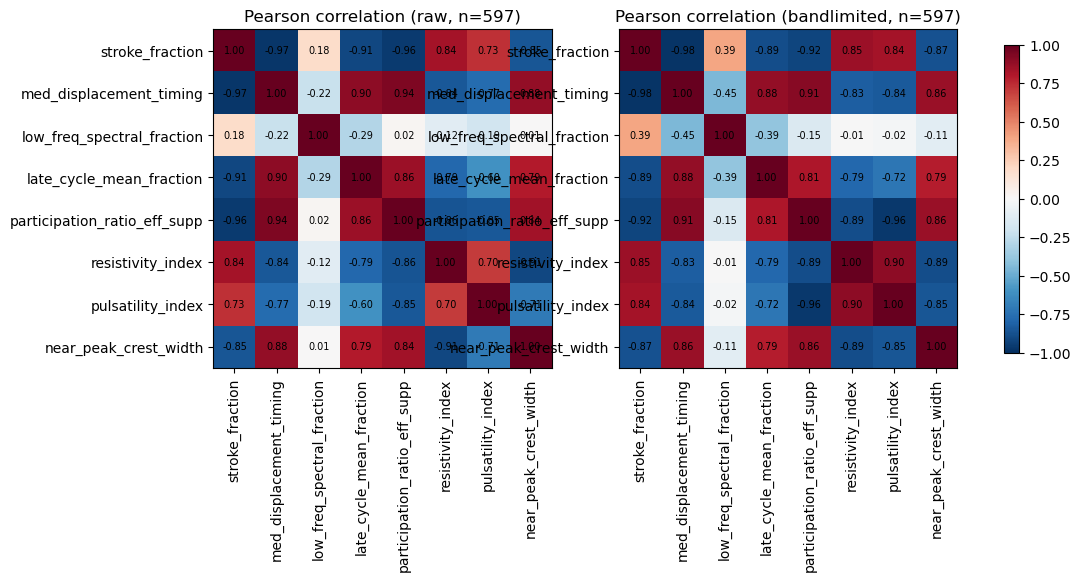

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(REPRESENTATIONS), figsize=(6 * len(REPRESENTATIONS), 5))
for ax, representation in zip(axes, REPRESENTATIONS):
    corr = correlations[representation]["pearson"]
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(metric_cols)))
    ax.set_xticklabels(metric_cols, rotation=90)
    ax.set_yticks(range(len(metric_cols)))
    ax.set_yticklabels(metric_cols)
    ax.set_title(f"Pearson correlation ({representation}, n={correlations[representation]['n']})")
    for i in range(len(metric_cols)):
        for j in range(len(metric_cols)):
            ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=axes, shrink=0.8)
plt.show()


In [9]:
# Quantify how much each metric's correlation with low_freq_spectral_fraction
# shifts between representations (bandlimited - raw), sorted by |shift|.
spectral_col = "low_freq_spectral_fraction"
raw_corr = correlations["raw"]["pearson"][spectral_col]
bandlimited_corr = correlations["bandlimited"]["pearson"][spectral_col]

diff = pd.DataFrame({
    "domain": [metric_to_domain[m] for m in metric_cols if m != spectral_col],
    "raw_r": [raw_corr[m] for m in metric_cols if m != spectral_col],
    "bandlimited_r": [bandlimited_corr[m] for m in metric_cols if m != spectral_col],
}, index=[m for m in metric_cols if m != spectral_col])
diff["abs_shift"] = (diff["bandlimited_r"] - diff["raw_r"]).abs()
diff.sort_values("abs_shift", ascending=False).round(3)

,domain,raw_r,bandlimited_r,abs_shift
med_displacement_timing,timing,-0.220,-0.449,0.229
stroke_fraction,timing,0.183,0.395,0.212
pulsatility_index,pulsatility,-0.194,-0.020,0.174
participation_ratio_eff_supp,persistence,0.018,-0.146,0.164
near_peak_crest_width,persistence,0.006,-0.109,0.115
resistivity_index,pulsatility,-0.117,-0.006,0.111
late_cycle_mean_fraction,persistence,-0.293,-0.393,0.100


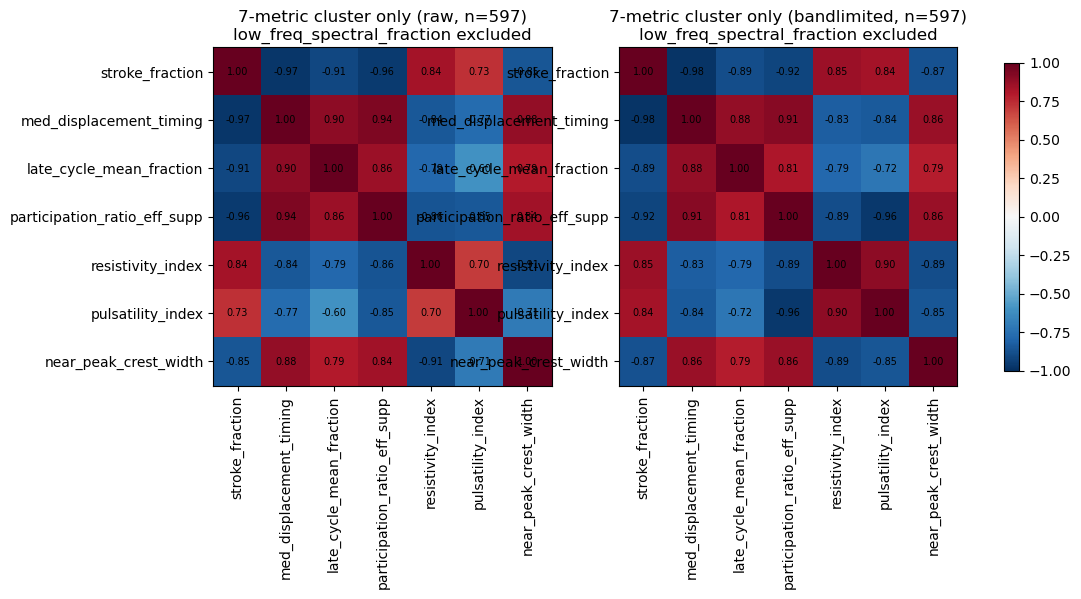

raw: min |r| = 0.60, median |r| = 0.85, max |r| = 0.97
bandlimited: min |r| = 0.72, median |r| = 0.86, max |r| = 0.98


In [10]:
cluster_cols = [m for m in metric_cols if m != "low_freq_spectral_fraction"]

fig, axes = plt.subplots(1, len(REPRESENTATIONS), figsize=(6 * len(REPRESENTATIONS), 5))
for ax, representation in zip(axes, REPRESENTATIONS):
    corr = correlations[representation]["pearson"].loc[cluster_cols, cluster_cols]
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(cluster_cols)))
    ax.set_xticklabels(cluster_cols, rotation=90)
    ax.set_yticks(range(len(cluster_cols)))
    ax.set_yticklabels(cluster_cols)
    ax.set_title(
        f"7-metric cluster only ({representation}, n={correlations[representation]['n']})\n"
        "low_freq_spectral_fraction excluded"
    )
    for i in range(len(cluster_cols)):
        for j in range(len(cluster_cols)):
            ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=axes, shrink=0.8)
plt.show()

cluster_r = correlations["raw"]["pearson"].loc[cluster_cols, cluster_cols].values
off_diag = cluster_r[~np.eye(len(cluster_cols), dtype=bool)]
print(f"raw: min |r| = {abs(off_diag).min():.2f}, median |r| = {np.median(abs(off_diag)):.2f}, max |r| = {abs(off_diag).max():.2f}")
cluster_r_bl = correlations["bandlimited"]["pearson"].loc[cluster_cols, cluster_cols].values
off_diag_bl = cluster_r_bl[~np.eye(len(cluster_cols), dtype=bool)]
print(f"bandlimited: min |r| = {abs(off_diag_bl).min():.2f}, median |r| = {np.median(abs(off_diag_bl)):.2f}, max |r| = {abs(off_diag_bl).max():.2f}")

In [11]:
cluster_cols = [m for m in metric_cols if m != "low_freq_spectral_fraction"]

cohort_rows = []
for (cohort, group), sub in wide_df.groupby(["cohort", "group"]):
    for representation in REPRESENTATIONS:
        subset = sub.loc[sub["representation"] == representation, cluster_cols + ["low_freq_spectral_fraction"]].dropna()
        n = len(subset)
        if n < 3:
            continue
        cluster_corr = subset[cluster_cols].corr(method="pearson").values
        off_diag = cluster_corr[~np.eye(len(cluster_cols), dtype=bool)]
        spectral_corr = subset[cluster_cols].corrwith(subset["low_freq_spectral_fraction"])
        cohort_rows.append({
            "cohort": cohort,
            "group": group,
            "representation": representation,
            "n": n,
            "cluster_median_abs_r": np.median(np.abs(off_diag)),
            "cluster_min_abs_r": np.abs(off_diag).min(),
            "cluster_max_abs_r": np.abs(off_diag).max(),
            "spectral_mean_abs_r": spectral_corr.abs().mean(),
        })

cohort_corr_df = pd.DataFrame(cohort_rows).sort_values(["n"], ascending=False).reset_index(drop=True)
pd.set_option("display.max_rows", None)
cohort_corr_df.round(2)

,cohort,group,representation,n,cluster_median_abs_r,cluster_min_abs_r,cluster_max_abs_r,spectral_mean_abs_r
0,POAG_vs_CTRL,CTRL,bandlimited,260,0.79,0.52,0.97,0.24
1,POAG_vs_CTRL,CTRL,raw,260,0.79,0.33,0.97,0.24
2,POAG_vs_CTRL,POAG,bandlimited,241,0.89,0.74,0.99,0.24
3,POAG_vs_CTRL,POAG,raw,241,0.90,0.79,0.98,0.13
4,GLONGI_select,before,bandlimited,15,0.95,0.64,1.00,0.51
5,GLONGI_select,before,raw,15,0.94,0.67,0.99,0.14
6,alternate_pressure,pressure,bandlimited,13,0.94,0.80,0.99,0.34
7,alternate_pressure,pressure,raw,13,0.95,0.82,0.99,0.34
8,alternate_pressure,ctrl,bandlimited,13,0.98,0.95,1.00,0.15
9,alternate_pressure,ctrl,raw,13,0.98,0.93,1.00,0.14


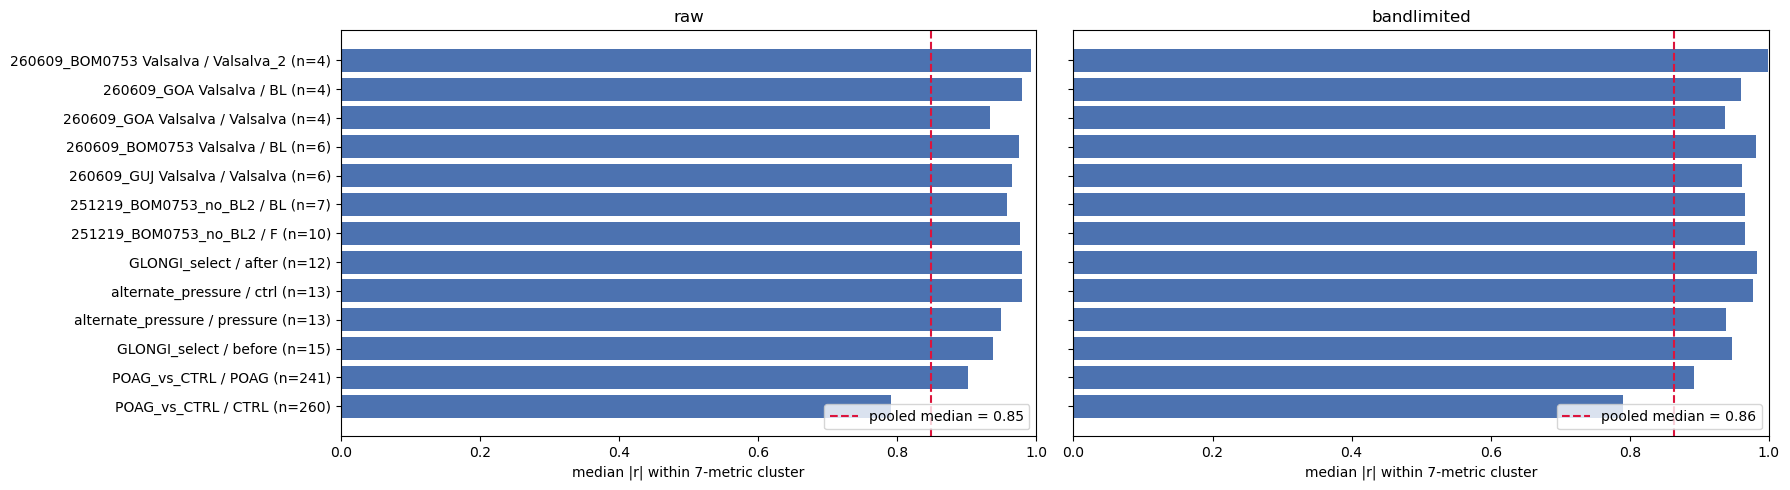

In [12]:
pooled_median = {
    representation: np.median(np.abs(
        correlations[representation]["pearson"].loc[cluster_cols, cluster_cols].values[
            ~np.eye(len(cluster_cols), dtype=bool)
        ]
    ))
    for representation in REPRESENTATIONS
}

fig, axes = plt.subplots(1, len(REPRESENTATIONS), figsize=(9 * len(REPRESENTATIONS), 5), sharey=True)
for ax, representation in zip(axes, REPRESENTATIONS):
    sub = cohort_corr_df[cohort_corr_df["representation"] == representation].copy()
    labels = sub["cohort"] + " / " + sub["group"] + " (n=" + sub["n"].astype(str) + ")"
    ax.barh(labels, sub["cluster_median_abs_r"], color="#4C72B0")
    ax.axvline(pooled_median[representation], color="crimson", linestyle="--", label=f"pooled median = {pooled_median[representation]:.2f}")
    ax.set_xlim(0, 1)
    ax.set_xlabel("median |r| within 7-metric cluster")
    ax.set_title(f"{representation}")
    ax.legend(loc="lower right")
plt.tight_layout()
plt.show()